_Neural Data Science_

Lecturer: Prof. Dr. Philipp Berens, Dr. Jan Lause

Tutors: Jonas Beck, Kyra Kadhim, Jonathan Oesterle, Julius Würzler

Summer term 2026

Student names: <span style='background: yellow'>*Andre Pothoff, Lucía Grande, Niclas Collmer* </span>

LLM Disclaimer: <span style='background: yellow'>*Did you use an LLM to solve this exercise? If yes, which?  Where and how did you use it? [Copilot, ChatGPT, Claude-Code etc.]* </span>
I used Gemini ones I got stuck, but first tried to do it on my own. Heavy use of gemini in the log-ification of the mog, the plotting of the final points, and the m-step in general. Bonus task and task 5 not attempted.

# Coding Lab 2

## Introduction

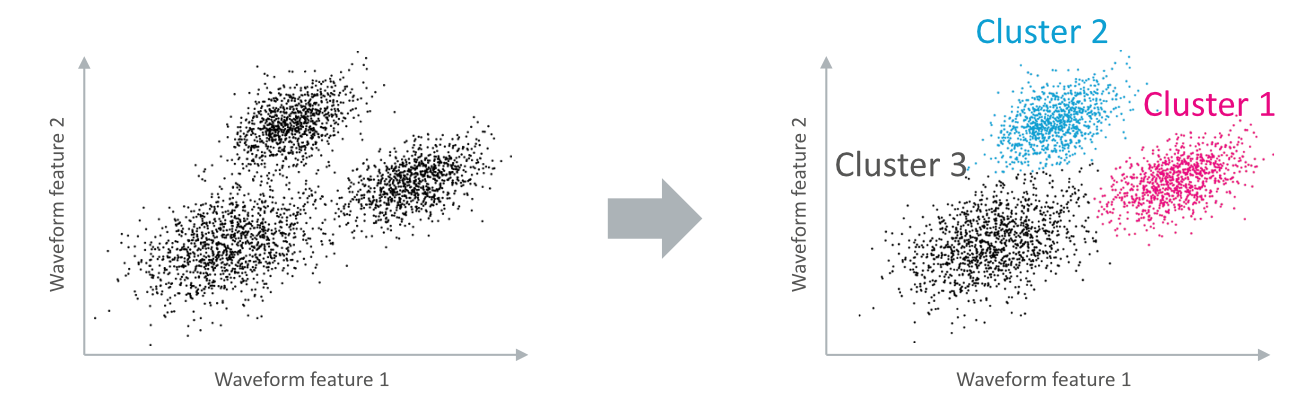

In this coding lab, we continue with the data from the first coding lab and finalize the Spike Sorting pipeline.
In particular, we use the created feature space to identify individual clusters by fitting a Gaussian Mixture Model.
To verify that this model does what we want, we first create a synthetic Toy Dataset and apply the model to that.

- __Data__: Use the saved data `nds_cl_1_*.npy` from Coding Lab 1. Or, if needed, download the data files ```nds_cl_1_*.npy``` from ILIAS and save it in the subfolder ```../data/```.
- __Dependencies__: You don't have to use the exact versions of all the dependencies in this notebook, as long as they are new enough. But if you run "Run All" in Jupyter and the boilerplate code breaks, you probably need to upgrade them.

In [2]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from __future__ import annotations

%load_ext jupyter_black

%load_ext watermark
%watermark --time --date --timezone --updated --python --iversions --watermark -p sklearn

Last updated: 2026-05-01 21:49:11 Romance Summer Time

Python implementation: CPython
Python version       : 3.12.10
IPython version      : 8.18.1

sklearn: 1.7.1

matplotlib: 3.10.3
numpy     : 2.0.1
pandas    : 2.2.3
scipy     : 1.13.1
sklearn   : 1.7.1

Watermark: 2.6.0



In [3]:
plt.style.use("../matplotlib_style.txt")

## Load data

In [4]:
# replace by path to your solutions
b = np.load("../data/nds_cl_1_features.npy")
s = np.load("../data/nds_cl_1_spiketimes_s.npy")
t = np.load("../data/nds_cl_1_spiketimes_t.npy")
w = np.load("../data/nds_cl_1_waveforms.npy")

## Task 1: Generate toy data

Sample 1000 data points from a two dimensional mixture of Gaussian model with three clusters  and the following parameters:

$\mu_1 = \begin{bmatrix}0\\0\end{bmatrix}, \Sigma_1 = \begin{bmatrix}1 & 0\\0 & 1\end{bmatrix}, \pi_1=0.3$

$\mu_2 = \begin{bmatrix}5\\1\end{bmatrix}, \Sigma_2 = \begin{bmatrix}2 & 1\\1 & 2\end{bmatrix}, \pi_2=0.5$

$\mu_3 = \begin{bmatrix}0\\4\end{bmatrix}, \Sigma_3 = \begin{bmatrix}1 & -0.5\\-0.5 & 1\end{bmatrix}, \pi_3=0.2$

Plot the sampled data points and indicate in color the cluster each point came from. Plot the cluster means as well.

*Grading: 2 pts*


In [5]:
def sample_data(
    n_samples: int, m: np.ndarray, S: np.ndarray, p: np.ndarray, random_seed: int = 0
) -> tuple[np.ndarray, np.ndarray]:
    """Generate n_samples samples from a Mixture of Gaussian distribution with
    means m, covariances S and priors p.

    Parameters
    ----------

    n_samples: int
        Number of samples

    m: np.ndarray, (n_clusters, n_dims)
        Means

    S: np.ndarray, (n_clusters, n_dims, n_dims)
        Covariances

    p: np.ndarray, (n_clusters, )
        Cluster weights / probablities

    random_seed: int
        Random Seed

    Returns
    -------

    labels: np.array, (n_samples, )
        Grund truth labels.

    x: np.array, (n_samples, n_dims)
        Data points
    """
    # ensure reproducibility using a random number generator
    # hint: access random functions of this generator
    rng = np.random.default_rng(random_seed)

    # ------------------------------------------------------
    # draw labeled points from mixture of Gaussians (1 pt)
    # ------------------------------------------------------

    labels = rng.choice(a=range(1, len(p) + 1), size=n_samples, p=p)
    x = np.empty(shape=(n_samples, m.shape[1]))

    for i in range(len(p)):
        n_subsamples = np.count_nonzero(i + 1 == labels)
        samples = rng.multivariate_normal(mean=m[i], cov=S[i, :, :], size=n_subsamples)
        x[np.where(labels == i + 1)] = samples
    return labels, x

In [6]:
N = 1000  # total number of samples

p = np.array([0.3, 0.5, 0.2])  # percentage of each cluster
m = np.array([[0.0, 0.0], [5.0, 1.0], [0.0, 4.0]])  # means

S1 = np.array([[1.0, 0.0], [0.0, 1.0]])
S2 = np.array([[2.0, 1.0], [1.0, 2.0]])
S3 = np.array([[1.0, -0.5], [-0.5, 1.0]])
S = np.stack([S1, S2, S3])  # cov

labels, x = sample_data(N, m, S, p, random_seed=3)

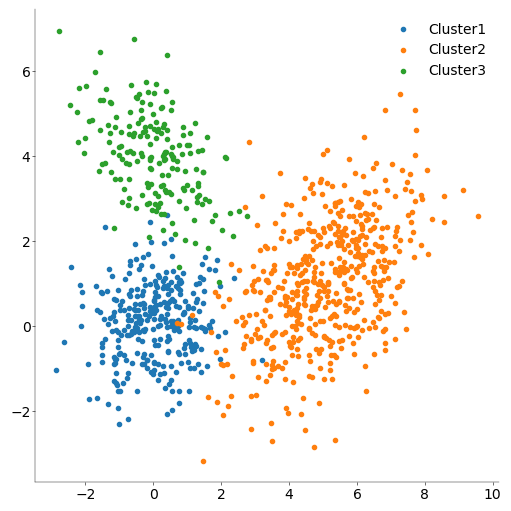

In [7]:
# ----------------------------------------------
# plot points from mixture of Gaussians (1 pt)
# ----------------------------------------------

fig, ax = plt.subplots(figsize=(5, 5), layout="constrained")

for i in range(len(p)):
    mask = labels == i + 1
    ax.scatter(x[mask, 0], x[mask, 1], label=f"Cluster{i+1}")
ax.legend()

## Task 2: Implement a Gaussian mixture model

Implement the EM algorithm to fit a Gaussian mixture model in `fit_mog()`.  Sort the data points by inferring their class labels from your mixture model (by using maximum a-posteriori classification). Fix the seed of the random number generator to ensure deterministic and reproducible behavior. Test it on the toy dataset specifying the correct number of clusters and make sure the code works correctly. Plot the data points from the toy dataset and indicate in color the cluster each point was assigned to by your model. How does the assignment compare to ground truth? If you run the algorithm multiple times, you will notice that some solutions provide suboptimal clustering solutions - depending on your initialization strategy.  

*Grading: 6 pts*


In [8]:
def fit_mog(
    x: np.ndarray,
    n_clusters: int,
    n_iters: int = 10,
    random_seed: int = 0,
    init: str = "random",
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Fit Mixture of Gaussian model using EM algo.

    Parameters
    ----------

    x: np.array, (n_samples, n_dims)
        Input data

    n_clusters: int
        Number of clusters

    n_iters: int
        Maximal number of iterations.

    random_seed: int
        Random Seed


    Returns
    -------

    labels: np.array, (n_samples)
        Cluster labels

    m: list or np.array, (n_clusters, n_dims)
        Means

    S: list or np.array, (n_clusters, n_dims, n_dims)
        Covariances

    p: list or np.array, (n_clusters, )
        Cluster weights / probablities
    """
    # ensure reproducibility using a random number generator
    rng = np.random.default_rng(random_seed)
    n_samples, n_dims = x.shape

    # -----------
    # init (1 pt)
    # -----------

    if init == "kmeans":
        km = KMeans(n_clusters=n_clusters, random_state=int(random_seed), n_init=5)
        km.fit(x)
        m = km.cluster_centers_.copy()
    else:  # random: pick random data points as initial means
        sample_idx = rng.choice(a=n_samples, size=n_clusters, replace=False)
        m = x[sample_idx].copy()

    # initialization of covariances as identity matrices
    S = np.broadcast_to(
        np.identity(n=n_dims)[np.newaxis, :, :], (n_clusters, n_dims, n_dims)
    ).copy()  # copy relevant because otherwise all covariances would share the same place in memory
    # initialize mixing coefficients uniformly
    p = np.ones((n_clusters)) / n_clusters

    log_rho = np.empty(shape=(n_clusters, n_samples))  # log of probabilities

    # -------------------------
    # EM maximisation (3 pts)
    # -------------------------

    for step in range(n_iters):
        # E step

        # Compute log N(x|m[c], S[c]) for each cluster c and data point x
        for c in range(n_clusters):
            log_pdf = sp.stats.multivariate_normal.logpdf(
                x=x,
                mean=m[c, :],
                cov=S[c, :, :],
                allow_singular=True,  # numerical instabilites
            )
            # Compute pi*N(x|m[c], S[c])
            log_rho[c, :] = np.log(p[c]) + log_pdf

        # Compute the denominator
        log_prob_norm = sp.special.logsumexp(log_rho, axis=0)

        # calculate gamma, the new estimation of cluster assignment: log(A/B) = log(A) - log(B)
        log_gamma = log_rho - log_prob_norm
        gamma = np.exp(log_gamma)

        # M step
        # Estimate new `m`, `S` and `p`
        for c in range(n_clusters):
            # effective number of data points assigned to cluster c
            N_c = np.maximum(np.sum(gamma[c, :]), 1e-6)  # avoid division by zero
            # Calculate the mean (using broadcasting vectorization (np.newaxis))
            m[c, :] = np.sum(gamma[c, :][:, np.newaxis] * x, axis=0) / N_c
            # Update Covariances
            diff = x - m[c, :]  # (helper, and only calculate it once)
            S[c, :, :] = (gamma[c, :][:, np.newaxis] * diff).T @ diff / N_c
            # 2. Force symmetric matrix (averaging it with its own transpose)
            S[c, :, :] = (S[c, :, :] + S[c, :, :].T) / 2.0
            # Tikhonov regularization (to make it positive definite)
            S[c, :, :] += np.eye(n_dims) * 1e-6
            p[c] = N_c / n_samples

    labels = (
        np.argmax(gamma, axis=0) + 1
    )  # +1 because of 0-indexing of labels vs label names

    return labels, m, S, p

Run Mixture of Gaussian on toy data

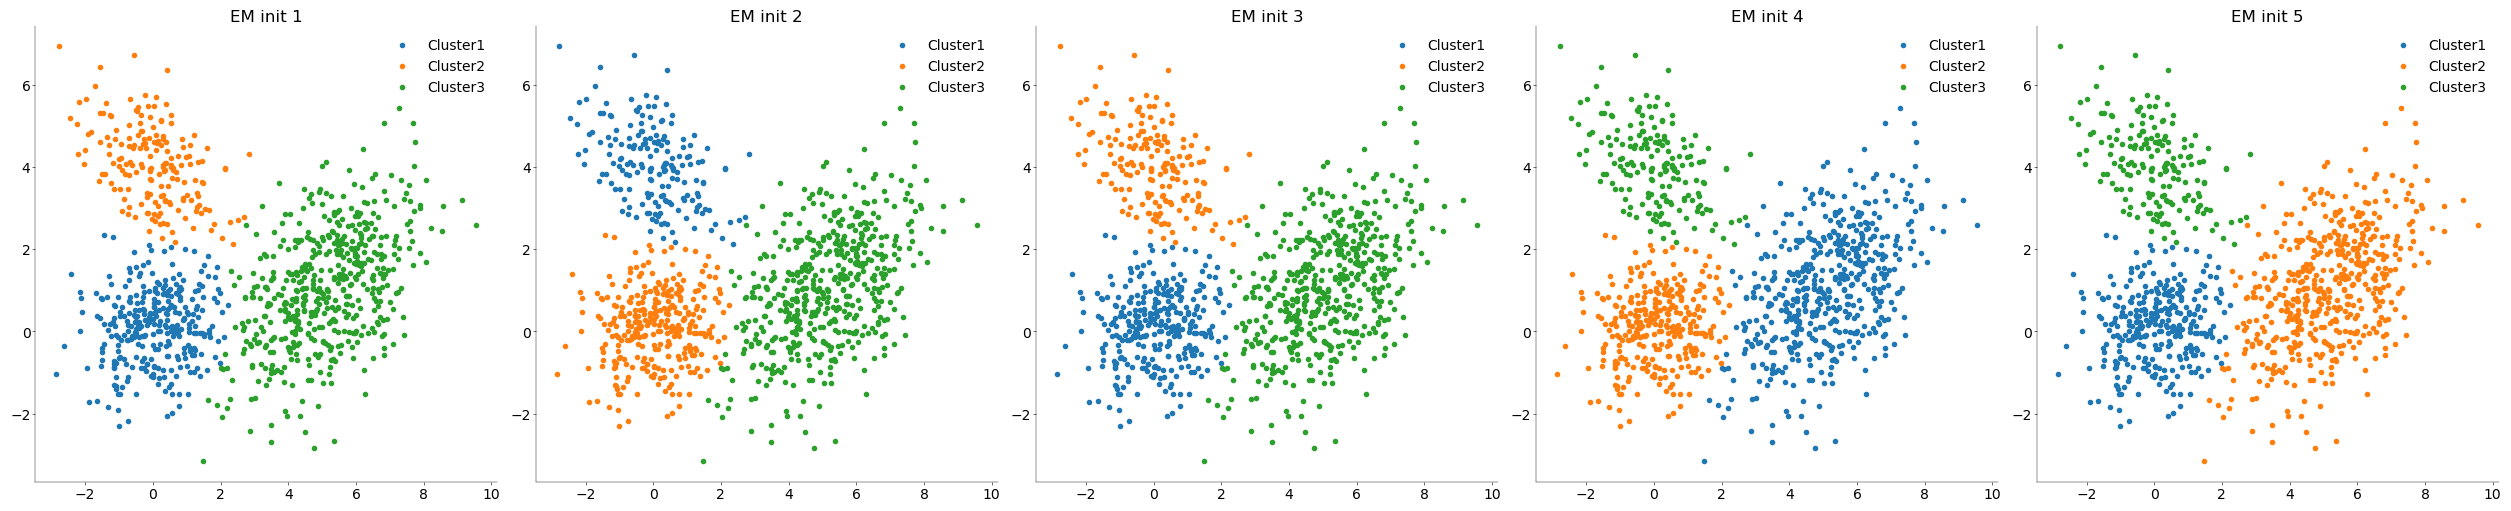

In [9]:
# -------------------------------------------------------------------------
# Run the algorithm with 5 random inits on the toy data, plot and compare original and
# assigned clusters and answer the questions (1+1 pts)
# -------------------------------------------------------------------------

n_inits = 5
fig, ax = plt.subplots(1, n_inits, figsize=(5 * n_inits, 5), layout="constrained")

for i in range(n_inits):
    new_labels, m, S, p = fit_mog(x, n_clusters=3, n_iters=1000, random_seed=i)
    for c in range(len(p)):
        mask = new_labels == c + 1
        ax[i].scatter(x[mask, 0], x[mask, 1], label=f"Cluster{c+1}")
    ax[i].set_title(f"EM init {i+1}")
    ax[i].legend()

### Questions

1) Do all runs converge to good solutions? If not, what are possible failure cases and how does the initialisation help?

most do, but not all of them (the last one is pretty bad). initialization with k_means could help. split and merge could help.

2) Do you get the same colors (=labels) in your best assignment(s) compared to the groundtruth? Does it have to be that way or not? Why?

no, we have no way of telling which one was cluster 1 or 2 or 3. but it also does not matter, since there is no inherent order

## Bonus Task (Optional): Mixture of drifting t-distributions

Instead of a simple Gaussian Mixture Model, more advanced algorithms can be implemented.
Implement a basic version of the mixture of drifting t-distributions (follow https://github.com/aecker/moksm/blob/master/MoT_Kalman.pdf).
What is the advantage of that method? You can verify your implementation using toy data, and then try to run it on the dataset below.

_Grading: 2 BONUS Points._


_BONUS Points do not count for this individual coding lab, but sum up to 5% of your **overall coding lab grade**. There are 4 BONUS points across all coding labs._

In [10]:
# YOUR CODE HERE

## Task 3: Model complexity
A priori we do not know how many neurons we recorded. Extend your algorithm with an automatic procedure to select the appropriate number of mixture components (clusters). Base your decision on the Bayesian Information Criterion:

$BIC = -2L+P \log N,$

where $L$ is the log-likelihood of the data under the best model, $P$ is the number of parameters of the model and $N$ is the number of data points. You want to minimize the quantity. Plot the BIC as a function of mixture components. What is the optimal number of clusters on the toy dataset?

You can also use the BIC to make your algorithm robust against suboptimal solutions due to local minima. Start the algorithm multiple times and pick the best solutions. You will notice that this depends a lot on which initialization strategy you use.

*Grading: 5 pts*



### Question (0.5 pts)

1) What is the number of parameters of the model? Explain your derivation?

$P = PI * \mu * \Sigma = K + KD + (D(D-1)/2)*K$

In [11]:
def mog_bic(
    x: np.ndarray, m: np.ndarray, S: np.ndarray, p: np.ndarray
) -> tuple[float, float]:
    """Compute the BIC for a fitted Mixture of Gaussian model

    Parameters
    ----------

    x: np.array, (n_samples, n_dims)
        Input data

    m: np.array, (n_clusters, n_dims)
        Means

    S: np.array, (n_clusters, n_dims, n_dims)
        Covariances

    p: np.array, (n_clusters, )
        Cluster weights / probablities

    Return
    ------

    bic: float
        BIC

    LL: float
        Log Likelihood
    """

    n_samples, n_dims = x.shape
    n_clusters = m.shape[0]

    # -------------------------
    # 1. Log Likelihood (Log Domain)
    # -------------------------
    log_rho = np.empty(shape=(n_clusters, n_samples))

    for c in range(n_clusters):
        # Evaluate directly in the log domain to prevent initial underflow
        log_pdf = sp.stats.multivariate_normal.logpdf(
            x,
            mean=m[c, :],
            cov=S[c, :, :],
            allow_singular=True,  # numerical instabilites
        )
        # log(p_c * N) = log(p_c) + log(N)
        log_rho[c, :] = np.log(p[c]) + log_pdf

    # Apply the Log-Sum-Exp across clusters to get the log marginal probability
    M_n = np.max(log_rho, axis=0)
    log_prob_norm = M_n + np.log(np.sum(np.exp(log_rho - M_n), axis=0))

    # The total log-likelihood is the sum of the log marginal probabilities across all N samples
    log_likelihood = np.sum(log_prob_norm)

    # -------------------------
    # 2. BIC Calculation
    # -------------------------
    # Compute the number of parameters: means + covariances + weights
    n_params = (
        n_clusters * n_dims + n_clusters * n_dims * (n_dims + 1) / 2 + (n_clusters - 1)
    )

    # Compute the BIC: k * ln(n) - 2 * ln(L)
    bic = n_params * np.log(n_samples) - 2 * log_likelihood

    return bic, log_likelihood

In [12]:
# ----------------------------------------------------------------------------------------------------------------------

K = np.arange(1, 8)
num_seeds = 10

BIC = np.zeros((num_seeds, len(K)))
LL = np.zeros((num_seeds, len(K)))

# run mog and BIC multiple times here

for i in range(num_seeds):
    for j, k in enumerate(K):
        new_labels, m, S, p = fit_mog(x, n_clusters=k, n_iters=300, random_seed=i)
        BIC[i, j], LL[i, j] = mog_bic(x, m, S, p)

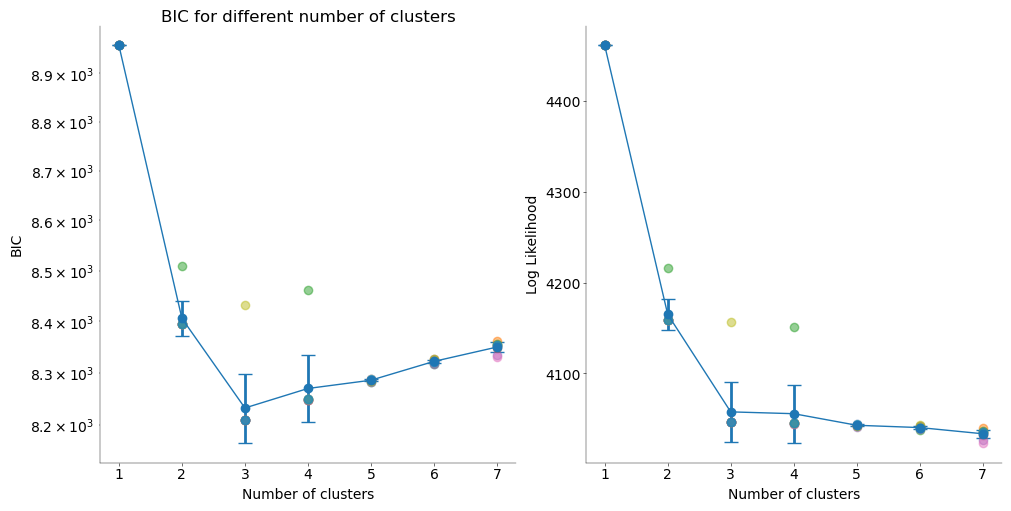

In [13]:
# ------------------------------------------------------------------------------------------
# Plot the result and answer the questions (1+1 pts)
# Don't forget to plot your robust estimate and highlight the estimated number of clusters!
# ------------------------------------------------------------------------------------------

BIC_no_inf = np.where(np.isinf(BIC), np.nan, BIC)

fig, ax = plt.subplots(1, 2, figsize=(10, 5), layout="constrained")

# Plot BIC
ax[0].errorbar(
    K,
    np.nanmean(BIC_no_inf, axis=0),
    yerr=np.nanstd(BIC_no_inf, axis=0),
    fmt="o-",
    elinewidth=2,
    capsize=5,
    label="BIC",
)
# also plot individual runs
for i in range(num_seeds):
    ax[0].plot(K, BIC_no_inf[i, :], "o", alpha=0.5)

# and LL
ax[1].errorbar(
    K,
    np.nanmean(-LL, axis=0),
    yerr=np.nanstd(-LL, axis=0),
    fmt="o-",
    elinewidth=2,
    capsize=5,
    label="Log Likelihood",
)
# and individual runs
for i in range(num_seeds):
    ax[1].plot(K, -LL[i, :], "o", alpha=0.5)

ax[0].set_xlabel("Number of clusters")
ax[0].set_ylabel("BIC")
ax[1].set_xlabel("Number of clusters")
ax[1].set_ylabel("Log Likelihood")
ax[0].set_yscale("log")
ax[0].set_title("BIC for different number of clusters")
ax[0].set_xticks(K)
plt.show()

### Questions

1) What happens to the BIC if the model got stuck in a local minimum? For your reasoning, you can also refer to Task 2.

The NLL stays above the global minimum and any intermediate action would increase it. the algorithm converges and finds a suboptimal solution. Therefore also the BIC is sub-optimal. 

1) The goal is to estimate which number of clusters best fits the data using the BIC. Therefore, what qualifies as a robust estimate? Explain your reasoning!
   
_(Hint: think about which number of cluster you would use and why)_

(If I did not know about the true number of clusters, ) I would go for the lowest BIC measured, which is the clustering with 3 clusters. even though, on average, this is not the optimal variant, it is the one when we do not account for suboptimal solutions.


## Task 4: Spike sorting using Mixture of Gaussian 
Run the full algorithm on your set of extracted features (MoG fitting + model complexity selection).

Show the plot of the BIC as a function of the number of mixture components on the real data, highlight the robust estimate and based on that the best number of clusters.

For the best model, make scatter plots of the first PCs on all four channels (6 plots). Color-code each data point according to its class label in the model with the optimal number of clusters. In addition, indicate the position (mean) of the clusters in your plot.

*Grading: 3 pts*


In [14]:
# -------------------------------------------------------------
# Run the algorithm on the set of extracted features (0.5 pts)
# -------------------------------------------------------------

# run it on the 12 PCAs extracted before

import tqdm

K = np.arange(2, 16)
num_seeds = 5

BIC = np.zeros((num_seeds, len(K)))
LL = np.zeros((num_seeds, len(K)))
results = list()

for i in tqdm.tqdm(range(num_seeds)):
    results_inner = list()
    for j, k in enumerate(K):
        labels, m, S, p = fit_mog(
            b, n_clusters=k, n_iters=20, random_seed=i, init="kmeans"
        )
        results_inner.append((labels, m, S, p))
        BIC[i, j], LL[i, j] = mog_bic(b, m, S, p)
    results.append(results_inner)

100%|██████████| 5/5 [33:54<00:00, 406.90s/it]


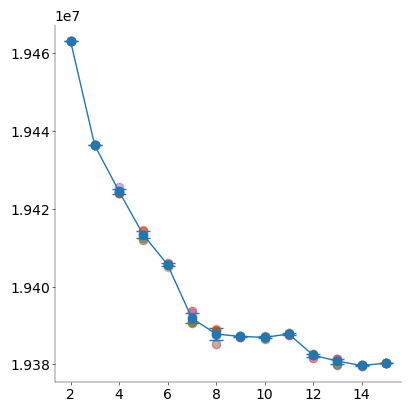

In [18]:
# ----------------------------------------------------------------------------------------------------------------------
# Plot the BIC over number of mixture components and highlight robust estimate and optimal number of clusters (0.5 pts)
# ----------------------------------------------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(4, 4))

BIC_no_inf = np.where(np.isinf(BIC), np.nan, BIC)

ax.errorbar(
    K,
    np.nanmean(BIC_no_inf, axis=0),
    yerr=np.nanstd(BIC_no_inf, axis=0),
    fmt="o-",
    elinewidth=2,
    capsize=5,
    label="BIC",
)
for i in range(num_seeds):
    ax.plot(K, BIC_no_inf[i, :], "o", alpha=0.5)

Refit model with lowest BIC and plot data points

In [19]:
random_seed, kk = np.where(BIC == BIC.min())
random_seed = random_seed[0]
kk = kk[0]
print(f"lowest BIC: # cluster = {K[kk]}")

lowest BIC: # cluster = 14


In [20]:
print(np.where(BIC_no_inf == np.min(BIC_no_inf)))
labels, m, S, p = results[4][12]

(array([4]), array([12]))


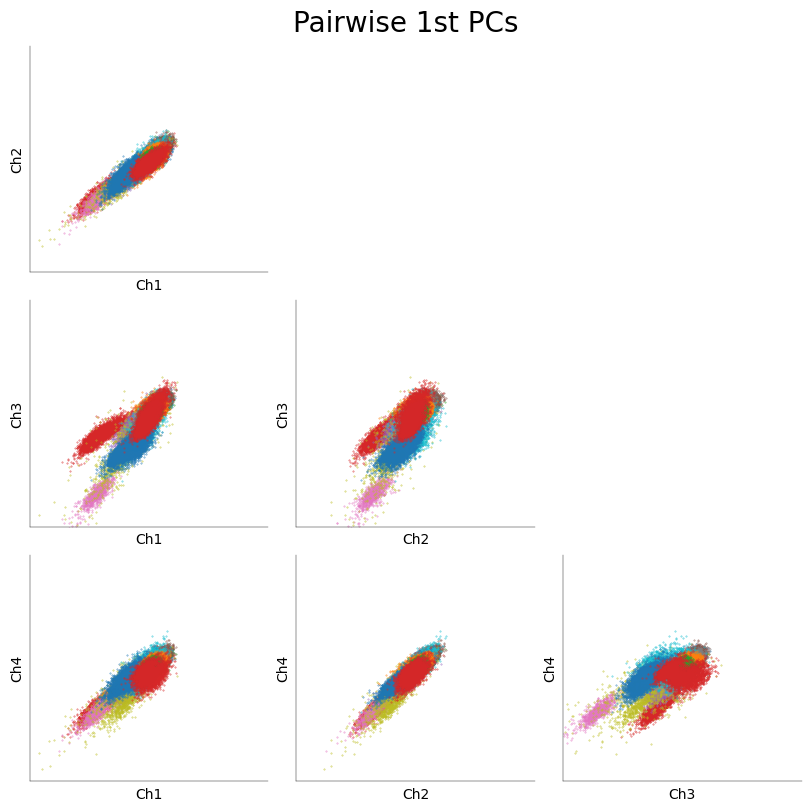

In [21]:
mosaic = [
    ["Ch2 vs Ch1", ".", "."],
    ["Ch3 vs Ch1", "Ch3 vs Ch2", "."],
    ["Ch4 vs Ch1", "Ch4 vs Ch2", "Ch4 vs Ch3"],
]
fig, ax = plt.subplot_mosaic(
    mosaic=mosaic, figsize=(8, 8), layout="constrained", dpi=100
)

# index of the 1st PC in `b`
i = {"Ch1": 0, "Ch2": 3, "Ch3": 6, "Ch4": 9}

for mo, axis in ax.items():
    y, x = mo.split(" vs ")

    for c in np.unique(labels):
        # Boolean mask for the current cluster
        mask = labels == c

        # Plot only the points belonging to cluster 'c'
        axis.scatter(
            b[mask, i[x]], b[mask, i[y]], s=0.5, label=f"Cluster {c}", alpha=0.8
        )

    axis.set_xlabel(x)
    axis.set_ylabel(y)
    axis.set_xlim((-1500, 1500))
    axis.set_ylim((-1500, 1500))
    axis.set_xticks([])
    axis.set_yticks([])

fig.suptitle("Pairwise 1st PCs", fontsize=20)
plt.show()

## Task 5: Cluster separation and Correlograms

As postprocessing, implement the calculation of auto- and cross correlograms over the spike times.

Plot the (auto-/cross-) correlograms, displaying a time frame of -30ms to +30ms. Choose a good bin size and interprete the resulting diagrams.

_Grading: 3 pts_

#### Hints

_It is faster to calculate the histogram only over the spiketimes that are in the displayed range. Filter the spike times before calculating the histogram!_

_For the autocorrelogram, make sure not to include the time difference between a spike and itself (which would be exactly 0)_

_For the correlogram an efficient implementation is very important - looping over all spike times is not feasible. Instead, make use of numpy vectorization and broadcasting - you can use functions such as tile or repeat._

In [ ]:
# ----------------------------------------------------------------------
# Implement a function for calculating the spike time differences (1pt)
# ----------------------------------------------------------------------
def cross_time_diff(spiketimes1: np.ndarray, spiketimes2: np.ndarray) -> np.ndarray:
    """Compute the pairwise time differences between two sets of spike times.

    Parameters
    ----------
    spiketimes1: np.ndarray, (n_spikes1, )
        Spike times of the first cluster
    spiketimes2: np.ndarray, (n_spikes2, )
        Spike times of the second cluster

    Return
    ------

    time_diff: np.ndarray, (n_spikes1, n_spikes2)
        Pairwise time differences between the two sets of spike times
        (i.e., spiketimes1[i] - spiketimes2[j])
    """
    pass

In [ ]:
# -----------------------------------------------------------------------------------
# Calculate and plot auto- and cross correlograms and answer the questions (1+1 pts)
# -----------------------------------------------------------------------------------

### Questions
1) Based on the plot, do you see clusters that contain spikes likely from a single neuron?

_YOUR ANSWER HERE_

2) Do you see cases where plural clusters might come from the same neuron?

_YOUR ANSWER HERE_

3) Do you see clusters that might contain spikes from plural neurons?

_YOUR ANSWER HERE_

4) Explain the term "refractory period" and how one can see it in this plot.

_YOUR ANSWER HERE_